In [28]:
# %pip install numpy
# %pip install matplotlib
# %pip install networkx
# %pip install scipy
# %pip install pandas
# %pip install joblib

In [29]:
#Import Modules
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import truncnorm
import time
from IPython.display import clear_output
import pandas as pd
from joblib import Parallel, delayed

Parameters:
1. Number Of Agents
2. Number of levels? Departments? Company Structure
3. Base Game Payoffs
4. Base Productivity
5. Initial Conditions: Integrity, Trust


In [40]:
class Agent: 
    def __init__(self, id, level, integrity, trust, mutation, game):
        self.id = id
        self.level = level
        self.integrity = integrity
        self.trust = trust
        self.mutation = mutation
        self.utility = 0
        self.strategy = 0
        self.payoff = np.array(game, dtype=float, copy=True)
        self.game = game
        self.results = {}
        self.bosses = []
        self.peers = []
        self.underlings = []
        self.underlings_cooperating = 0
    

        #game functions:
    # 
    # 
    # 
    
    def get_opponents(self, opponents): #gets lost of opponent of type keywarg (used for play_game function in update)

        if isinstance(opponents, str):
            if opponents == 'bosses':
                return self.bosses
            elif opponents == 'peers':
                return self.peers
            elif opponents == 'underlings':
                return self.underlings
            else: 
                raise KeyError('Opponent must = bosses, peers or underlings' )
        else:
            raise TypeError('Opponent must a string and = bosses, peers or underlings')    

         
    def update_payoff(self): #transform game matrix into individual payoffs
        scale = np.clip(self.integrity + self.trust, -2, 2)
        payoff = self.game.copy()
        payoff[0][0] = payoff[0][0] * scale
        payoff[0][1] = payoff[0][1] * scale
        payoff[1][0] = payoff[1][0]
        payoff[1][1] = payoff[1][1]

        self.payoff = payoff
        
        return self.payoff
    
    def expected_opponent_strategy(self, t, fraction_corrupt, opponent): #find expected opponent strategy (right now based on fraction cooperating and trus)

        #base expected strategy on fraction of corrupt agents in the population and trust
        if t > 0: expected_strategy = (1-fraction_corrupt[-1])*self.trust #maybe better equation for this
        else: expected_strategy = .5
        return expected_strategy    

    def pick_strategy(self, t, fraction_corrupt, opponent): #pick strategy to play in the game
        #get expected opp strategy
        expected_strategy = self.expected_opponent_strategy(t, fraction_corrupt, opponent)

        #update payoff matrix
        payoff_matrix = self.update_payoff()

        #get utilities for every payoff
        uCC = payoff_matrix[0][0]
        uCD = payoff_matrix[0][1]
        uDC = payoff_matrix[1][0]
        uDD = payoff_matrix[1][1]

        #handle mixed strategies
        denominator = uDC - uCC + uCD - uDD
        if np.isfinite(denominator) and abs(denominator) > 1e-12:
            indifference_guess = (uCD - uDD) / denominator #Above this weight the opponent could put on cooperate D > C
        else:
            indifference_guess = 0.5

        # pick strategy
        s = 0
        biggest_row = []
        #add mutation chance (pick randomly)
        if np.random.rand() < self.mutation: # adds a random mutation/deviation from the "rational" strategy
            s = np.random.choice([0,1], p=[.5,.5])
            return s 
        else: #pick pick strategy
            if uCC > uDC and uCD > uDD: #Check for dominant strategy (can make these stochastic or use different heuristic)
                s = 0
                return s
            elif uCC < uDC and uCD < uDD:
                s = 1
                return s
            elif expected_strategy > indifference_guess : #Check for best expectation (mixed strategy)
                s = 1
                return s
            else:
                s = 0
                return s
            
    def punish(self, punish_rate):
        
        if np.random.rand() < punish_rate:
            self.integrity = truncnorm.rvs(-1, 1, loc=1, scale=1)
            self.trust = truncnorm.rvs(-1, 1, loc=1, scale=1)

            return 1
        else: return 0
            
        
    #Dynamic variables
    #
    #
    #

    def d_utility(self, result):
        delta = .01 * self.payoff[result[0]][result[1]]
        if np.isfinite(delta):
            self.utility += delta
        return

    def d_trust(self, t):

        #Base on the utility that the oppenent recieved. If opponent defected and recieved higher utility, then trust should decrease 
        if t>0:
            last_round_strategies = list(self.results[t-1][0].values())

            peers_utility = []

            for peer in self.peers:
                peers_utility.append(peer.utility)
            if len(peers_utility) > 0:
                average_peer_utility = np.mean(peers_utility)
            else:
                average_peer_utility = None


            opp_def = 0
            result_count = 0

            for result in last_round_strategies:
                opp_def += result[1]
                result_count += 1


            if result_count > 0:

                fraction_def = opp_def/result_count
        
                if average_peer_utility > self.utility:
                    d_trust = .2*(np.tan(np.pi/2*(.5-fraction_def)))
                    if np.isfinite(d_trust):
                        self.trust = float(np.clip(self.trust + d_trust, -1, 1))
                    elif np.isposinf(d_trust):
                        self.trust = 1
                    elif np.isneginf(d_trust):
                        self.trust = -1
                    return
                else:
                    return
                
            

            
            
            
            
        


        

    
    


Option 1: generate agents with network -- I did this
Option 2: generate network then add agents
Option 3: generate agents then generate network

In [31]:
def generate_network(level_size, integrity_mean, trust_mean, mutation, game): #generate network with company structure

    G = nx.DiGraph()

    ceo = Agent(0, 'CEO', truncnorm.rvs(-1, 1, loc=integrity_mean, scale=1), truncnorm.rvs(-1, 1, loc=trust_mean, scale=1), mutation, game) #initialize top agent

    G.add_node(ceo.id, level=0, agent=ceo)
    nodes_this_level = [ceo.id]

    for level, size in enumerate(level_size):

        nodes_level = [] 

        for employee in range(size):

            id = len(G.nodes) #id for new node

            this_level = level + 1 #the current level is the index of the level_size list plus one (cause first level is ceo)

            #Initialize agent params
            integrity = truncnorm.rvs(-1, 1, loc=integrity_mean, scale=1)
            trust = truncnorm.rvs(-1, 1, loc=trust_mean, scale=1)

            #create employees at this level
            agent = Agent(id, this_level, integrity, trust, mutation, game)
            G.add_node(agent.id, level=this_level, agent=agent)

            #get list of employees this level
            nodes_level.append(agent)
            
            if this_level == 1: #if its the first level, the boss is the ceo

                G.add_edge(0, agent.id)

                #add to bosses and underlings attribute respectively
                agent.bosses.append(ceo)
                ceo.underlings.append(agent)

            else: #all other levels, the node randomly choses a boss from the previous level

                #pick random boss
                boss_id = np.random.choice([n for n, d in G.nodes(data=True) if d['level'] == this_level - 1])


                G.add_edge(boss_id, agent.id)

                #add to bosses and underlings attribute respectively
                agent.bosses.append(G.nodes[boss_id]['agent'])
                G.nodes[boss_id]['agent'].underlings.append(agent)

        #append employees to the level in nodes_this_level (used for peers)
        nodes_this_level.append(nodes_level)
        
        #make peer connections
        for employee in nodes_this_level[-1]:
            
            #for every node, connect to all peers
            for peer in nodes_this_level[-1]:

                if employee != peer: #avoid self edges

                    #add directional edges between both
                    G.add_edge(employee.id, peer.id)
                    G.add_edge(peer.id, employee.id)

                    #add to peer attribute
                    employee.peers.append(peer)
                    peer.peers.append(employee)
    return G

In [32]:
def initialize(level_size, integrity_mean, trust_mean, mutation):
  
    #prisoners dilemma matrix
    uCC = .75
    uCD = .1
    uDC = 1
    uDD = .5

    game = np.array([[uCC, uCD],
                     [uDC, uDD]])

    G = generate_network(level_size, integrity_mean, trust_mean, mutation, game)
    return G

In [33]:
def play_game(t, fraction_corrupt, node, punish_rate, opponents = str):

    opps = node.get_opponents(opponents)
    results = {}
    
    num_def = 0
    num_g = 0

    punish_count = 0

    for opponent in opps:

        opp_strat = 0
        node_strat = 0

        opp_strat = opponent.pick_strategy(t, fraction_corrupt, node)
        node_strat = node.pick_strategy(t, fraction_corrupt, opponent)

        node_result = (node_strat, opp_strat)
        opp_result = (opp_strat, node_strat)

        results[opponent.id] = node_result

        node.d_utility(node_result)
        opponent.d_utility(opp_result)

        if node_strat == 1:
            punish_count += node.punish(punish_rate)

        if opp_strat == 1:
            punish_count += opponent.punish(punish_rate)

        num_def += opp_strat + node_strat

        num_g += 2

        
        
        


    return results, num_def, num_g, punish_count

In [34]:
def update(G, t, fraction_corrupt, punish_rate):
    next_G = G
    results = []
    count_corrupt_t = 0
    games_count_t = 0
    punished_count = 0
    
    for n in G.nodes:

        node = G.nodes[n]['agent']

        #Play game with peers
        r_peers, num_defects_peers, num_games_peers, punish_count_peers = play_game(t, fraction_corrupt, node, punish_rate, 'peers')
        r_underlings, num_defects_underlings, num_games_underlings, punish_count_underlings = play_game(t, fraction_corrupt, node, punish_rate, 'underlings')
        

        node.results[t] = (r_peers, r_underlings)

        count_corrupt_t += num_defects_peers + num_defects_underlings

        results.append(node.results[t])

        games_count_t += num_games_peers + num_games_underlings

        punished_count += punish_count_peers + punish_count_underlings

    for n in G.nodes:

        node = G.nodes[n]['agent']

        node.d_trust(t)

    fraction_corrupt_t = count_corrupt_t/games_count_t
    return next_G, fraction_corrupt_t, results, punished_count, count_corrupt_t

In [35]:
def plot_network(G, trusts, utilities):

    def normalize_data(data):
        return (data - np.min(data)) / (np.max(data) - np.min(data))

    pos = nx.kamada_kawai_layout(G)

    levels = np.array([G.nodes[n]['level'] for n in G.nodes])

    # integrities = np.array([G.nodes[n]['agent'].integrity for n in G.nodes])

    # trusts = np.array([G.nodes[n]['agent'].trust for n in G.nodes])

    sizes = 1800 / (levels + 1)

    trust_network = plt.figure(figsize=(10, 7))

    nx.draw_networkx_edges(G, pos, alpha=0.35, arrows=True, arrowstyle='-|>', arrowsize=12)

    #nodes = nx.draw_networkx_nodes(G, pos, node_color=integrities, node_size=sizes, cmap='RdYlGn', vmin=-1, vmax=1)

    nodes = nx.draw_networkx_nodes(G, pos, node_color=trusts, node_size=sizes, cmap='RdYlGn', vmin=-1, vmax=1)

    nx.draw_networkx_labels(G, pos, font_size=8)

    #plt.colorbar(nodes, label='Integrity')
    plt.colorbar(nodes, label='Trust')

    plt.axis('off')
    
    plt.show()

    utility_network = plt.figure(figsize=(10, 7))

    nx.draw_networkx_edges(G, pos, alpha=0.35, arrows=True, arrowstyle='-|>', arrowsize=12)

    #nodes = nx.draw_networkx_nodes(G, pos, node_color=integrities, node_size=sizes, cmap='RdYlGn', vmin=-1, vmax=1)

    nodes = nx.draw_networkx_nodes(G, pos, node_color=normalize_data(utilities), node_size=sizes, cmap='viridis', vmin=0, vmax=1)

    nx.draw_networkx_labels(G, pos, font_size=8)

    #plt.colorbar(nodes, label='Integrity')
    plt.colorbar(nodes, label='Utility')

    plt.axis('off')

    plt.show()



In [36]:
def observe(G, model_data, trusts, utilities):

    #Plot network
    plot_network(G, trusts, utilities)

    #Plot Data

    #Fraction Corrupt
    fig1 = plt.Figure((10,6))
    plt.plot(model_data.fraction_corrupt)
    plt.show()

    #Mean Trust
    fig2 = plt.Figure((10,6))
    model_data.mean_trust.plot(kind = 'line', title = 'Mean Trust Over Time', xlabel = 'Time', ylabel = 'Mean Trust', label = 'Mean Trust')
    plt.show()

    #Mean Utility
    fig3 = plt.Figure((10, 6))
    plt.plot(model_data.mean_utility)
    plt.show()

    

In [37]:
def run(time_steps, level_size = [3, 9], integrity_mean=0, trust_mean=0, mutation=0, plot = False, final_plot = True):
    N = np.sum(level_size)
    G = initialize(level_size, integrity_mean, trust_mean, mutation)
    punish_rate = .01
    fraction_corrupt = []

    model_data = pd.DataFrame(columns=['time_step', 'fraction_corrupt', 'count_corrupt', 'mean_trust', 'mean_utility', 'results', 'count_punished'])

    for t in range(time_steps):
        G, fraction_corrupt_t, results, punished_count, corrupt_count = update(G, t, fraction_corrupt, punish_rate)

        trusts = []

        for n in G.nodes: 
            trusts.append(G.nodes[n]['agent'].trust)

        mean_trust = np.mean(trusts)

        utilities = []

        for n in G.nodes: 
            utilities.append(G.nodes[n]['agent'].utility)

        mean_utility = np.mean(utilities)

        row_data = {
            'time_step': t,
            'fraction_corrupt': fraction_corrupt_t,
            'count_corrupt': corrupt_count,
            'mean_trust': mean_trust,
            'mean_utility': mean_utility,
            'results': results,
            'count_punished': punished_count

        }

        model_data.loc[len(model_data)] = row_data

        fraction_corrupt.append(fraction_corrupt_t)

        if plot:
            observe(G, model_data, trusts, utilities)
            clear_output(wait=True)
            time.sleep(.05)
            
    if final_plot:
        observe(G, model_data, trusts, utilities)
    
    return G, model_data


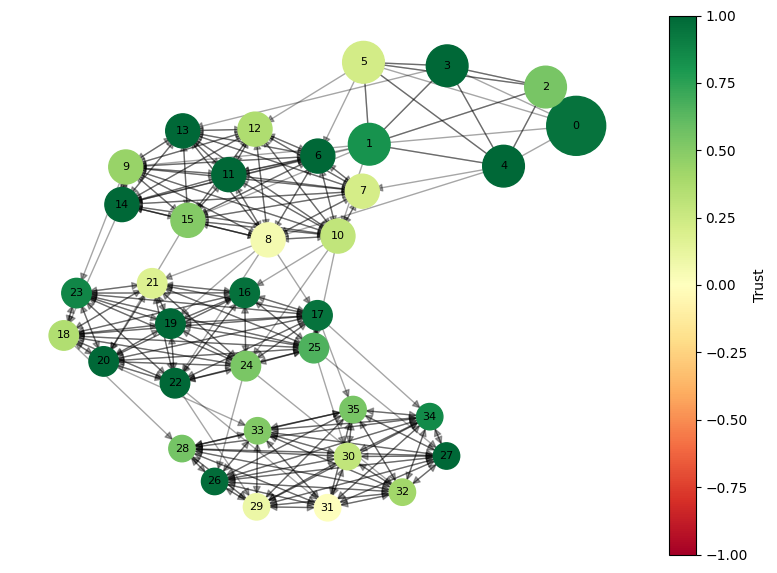

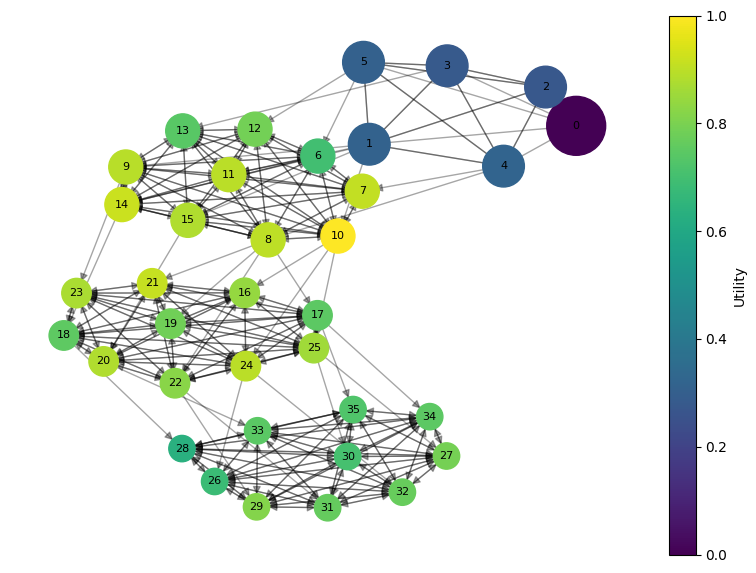

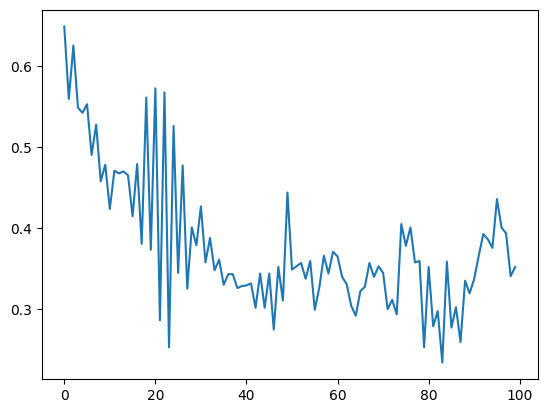

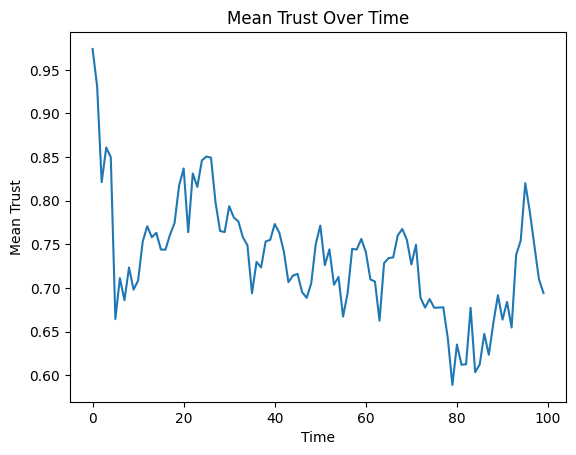

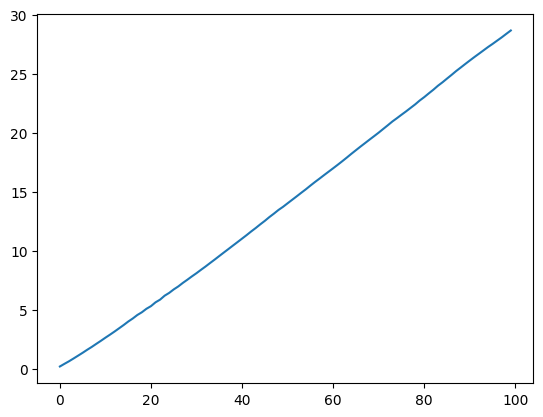

In [41]:
G, model_data = run(100, [5, 10, 10, 10], .5, 1, .1, False)

In [39]:

display(model_data)

G.nodes[1]



,time_step,fraction_corrupt,count_corrupt,mean_trust,mean_utility,results,count_punished
0,0,0.626829,771,0.871001,0.212804,"[({}, {1: (1, 1), 2: (1, np.int64(0)), 3: (1, ...",7
1,1,0.620325,763,0.607526,0.425205,"[({}, {1: (1, 1), 2: (1, 1), 3: (np.int64(0), ...",4
2,2,0.730081,898,0.462206,0.616436,"[({}, {1: (1, 1), 2: (1, 1), 3: (1, np.int64(1...",5
3,3,0.752033,925,0.298396,0.806779,"[({}, {1: (1, 1), 2: (1, 1), 3: (1, 0), 4: (1,...",10
4,4,0.847967,1043,0.222321,0.983521,"[({}, {1: (1, 1), 2: (np.int64(0), np.int64(0)...",8
...,...,...,...,...,...,...,...
95,95,0.891870,1097,-0.348655,16.665170,"[({}, {1: (1, np.int64(0)), 2: (1, 1), 3: (1, ...",11
96,96,0.895935,1102,-0.371985,16.837089,"[({}, {1: (1, 1), 2: (1, np.int64(0)), 3: (np....",9
97,97,0.917073,1128,-0.384186,17.008351,"[({}, {1: (1, 1), 2: (1, np.int64(1)), 3: (1, ...",6
98,98,0.911382,1121,-0.235382,17.181275,"[({}, {1: (np.int64(1), 1), 2: (1, 1), 3: (1, ...",14


{'level': 1, 'agent': <__main__.Agent at 0x11d3b87d0>}

agents ascribe strategy to all underlying based on perceptions
--> ascribe strategy to peers based on perceptions
--> ascribe strategy to superiors based on perceptions
Strategy expected payoffs are based on integrity, trust, and perceptions of others' strategies
cooperate cooperate results outcome: highest productivity for company
pay of boss is based on productivity of underlings 

agents update trust based on: person they can see (connected too) with highest utility: if that person is cooperating, they increase trust, if that person is defecting, they decrease trust.

agents update integrity on longer time scale (add later)

perception of others' strategies based on: trust (and history of interactions with them (add later))